# 01 - EDA: Customer Churn Dataset

Objetivo: entender la estructura del dataset, la distribución de `Exited`, detectar riesgos de data leakage y preparar el terreno para el diseño de `ChurnType` (notebook 02).

**Importante:** en este notebook NO construimos `ChurnType`. Solo exploramos el dataset.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/churn.csv')
df.shape

(10000, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Calidad de datos

Nulos, duplicados y cardinalidad de identificadores.

In [14]:
print('Nulos totales:', df.isnull().sum().sum())
print('CustomerId duplicados:', df['CustomerId'].duplicated().sum())
print('Surname valores unicos:', df['Surname'].nunique(), '/', len(df))

Nulos totales: 0
CustomerId duplicados: 0
Surname valores unicos: 2932 / 10000


**Conclusion:** dataset limpio, sin nulos, sin duplicados. `RowNumber`, `CustomerId` y `Surname` son identificadores sin poder predictivo real (o con riesgo de overfitting/leakage indirecto en el caso de `Surname`, que podria correlacionar espuriamente con `Geography`). Se excluiran como features del modelo.

## 2. Distribucion de la variable objetivo `Exited`

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


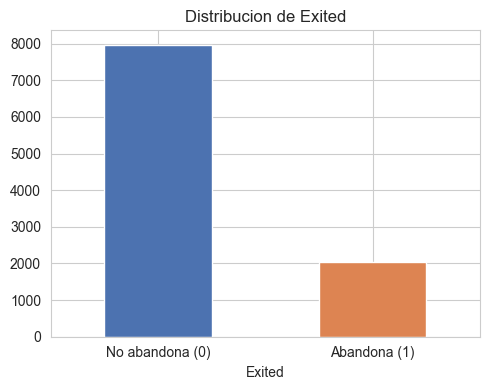

In [15]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(5,4))
df['Exited'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Distribucion de Exited')
ax.set_xticklabels(['No abandona (0)', 'Abandona (1)'], rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/eda/exited_distribution.png', dpi=120)
plt.show()

**Hallazgo clave:** ~20.4% de clientes abandonan (clases desbalanceadas 80/20). Esto tiene consecuencias directas para el proyecto:
- Accuracy sera una metrica poco fiable (un modelo que siempre prediga 'no churn' ya acertaria el 80%).
- Usaremos ROC-AUC, PR-AUC, Precision, Recall y F1 como metricas principales.
- Puede tener sentido usar `scale_pos_weight` en XGBoost o estratificar cuidadosamente el split (ya previsto en el enunciado).

## 3. Variables numericas: distribucion general

In [16]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


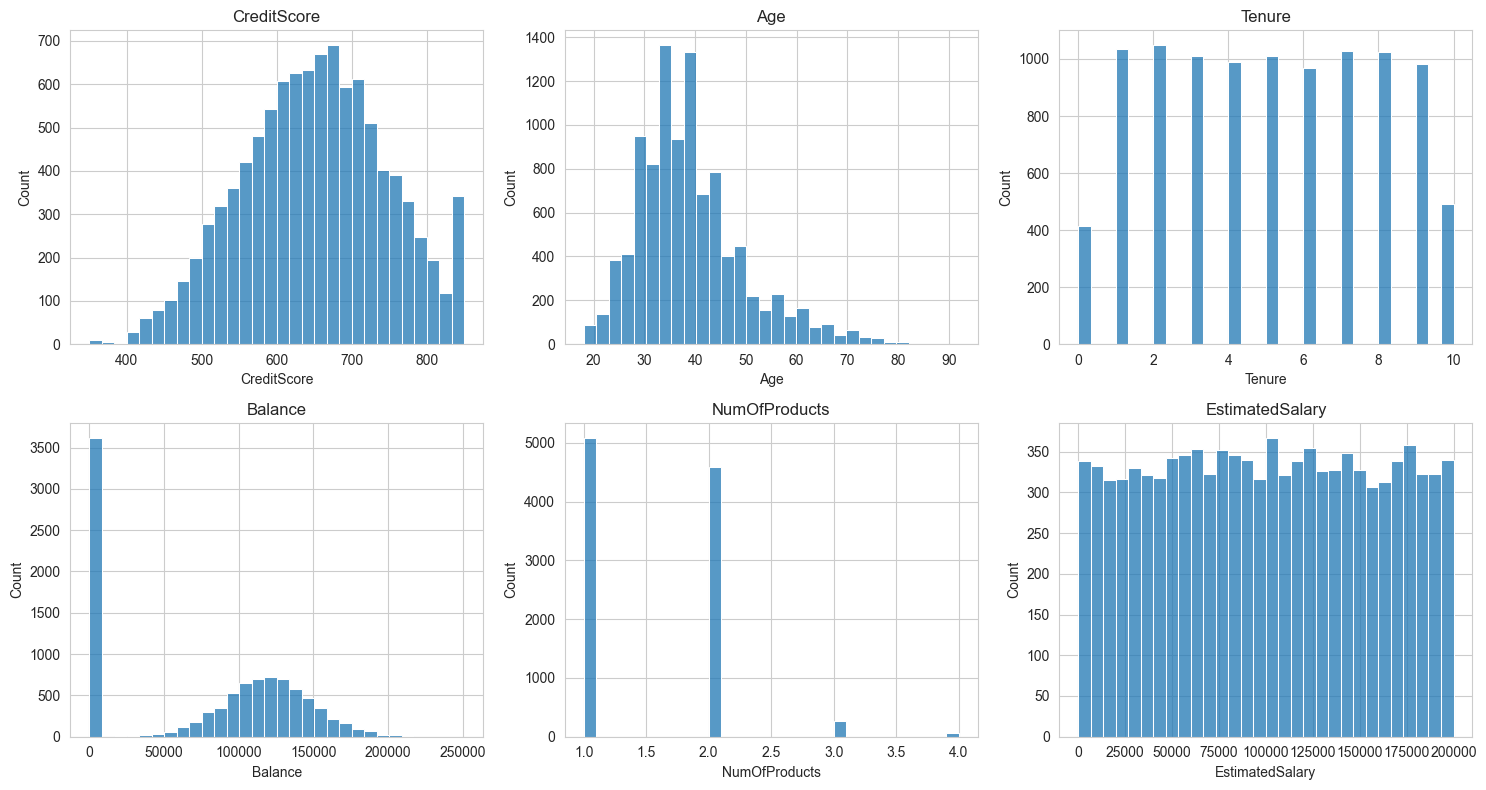

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax, bins=30, kde=False)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/figures/eda/numeric_distributions.png', dpi=120)
plt.show()

## 4. Caso especial: `Balance = 0`

Este es uno de los hallazgos mas importantes del EDA, con impacto directo en el diseno de `ChurnType` (notebook 02).

In [18]:
zero_balance_pct = (df['Balance'] == 0).mean() * 100
print(f'Clientes con Balance = 0: {(df["Balance"]==0).sum()} ({zero_balance_pct:.1f}%)')
print()
print('Estadisticas de Balance entre clientes con saldo > 0:')
print(df.loc[df['Balance'] > 0, 'Balance'].describe())

Clientes con Balance = 0: 3617 (36.2%)

Estadisticas de Balance entre clientes con saldo > 0:
count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: Balance, dtype: float64


**Hallazgo:** el 36.2% de los clientes tiene `Balance = 0`. Esto no es un dato faltante, sino un valor real y frecuente (probablemente cuentas sin saldo depositado o solo con productos como tarjeta de credito). Es una distribucion bimodal (masa en 0 + distribucion aproximadamente normal en el resto).

**Implicacion para `ChurnType`:** si normalizamos `Balance` con min-max, la masa en 0 comprime artificialmente la escala. Usaremos **normalizacion por rango percentil** (percentile rank) en lugar de min-max, que es robusta a esta bimodalidad.

## 5. Variables categoricas vs `Exited`

In [19]:
print('Exited rate por Geography:')
print(df.groupby('Geography')['Exited'].mean())
print()
print('Exited rate por Gender:')
print(df.groupby('Gender')['Exited'].mean())
print()
print('Exited rate por NumOfProducts:')
print(df.groupby('NumOfProducts')['Exited'].mean())
print()
print('Exited rate por IsActiveMember:')
print(df.groupby('IsActiveMember')['Exited'].mean())

Exited rate por Geography:
Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

Exited rate por Gender:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

Exited rate por NumOfProducts:
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Exited rate por IsActiveMember:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


**Hallazgos relevantes para el modelo, NO para ChurnType:**
- `Germany` tiene una tasa de abandono (32.4%) muy superior a `France` y `Spain` (~16%). Senal fuerte para XGBoost.
- `NumOfProducts`: relacion no lineal y muy fuerte. 1 producto -> 27.7% churn, 2 productos -> 7.6% churn (el mejor perfil), 3-4 productos -> 82-100% churn. Esto sugiere que tener demasiados productos puede ser sintoma de un cliente insatisfecho que ha probado varias soluciones sin exito, o clientes en proceso de salida con productos temporales. Feature muy potente para XGBoost.
- `IsActiveMember`: los inactivos abandonan casi el doble (26.8% vs 14.3%).

Estas variables son buenas **features de riesgo** (para XGBoost), pero como veremos en 02_business_rules, no las usaremos para definir el **impacto economico** (`ChurnType`), para no mezclar los dos conceptos.

## 6. Correlaciones numericas

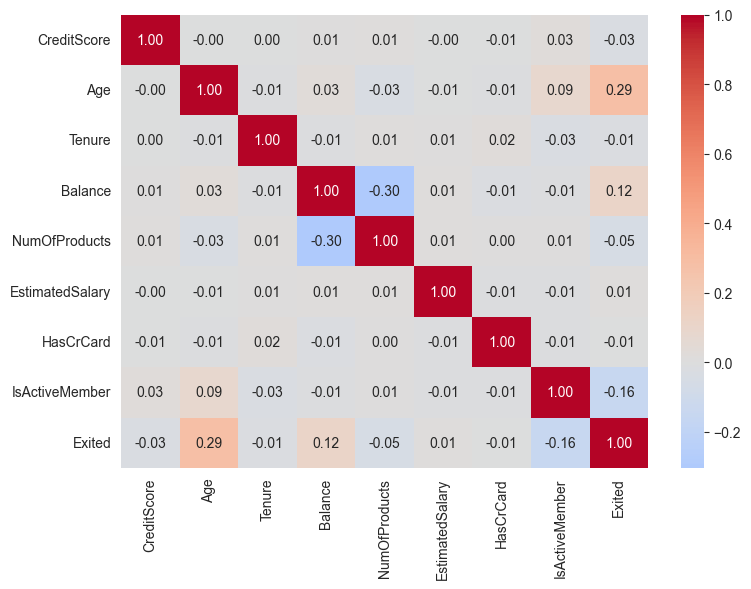

In [20]:
corr_cols = num_cols + ['HasCrCard', 'IsActiveMember', 'Exited']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.savefig('../reports/figures/eda/correlation_heatmap.png', dpi=120)
plt.show()

**Conclusion:** no hay correlaciones lineales fuertes entre variables numericas (multicolinealidad baja). `Age` es la variable numerica con mayor correlacion con `Exited`, aunque moderada. Esto es consistente con que XGBoost (modelo no lineal, basado en arboles) sea mas adecuado que un modelo lineal para este problema.

## 7. Analisis de data leakage

Reglas que fijamos para el resto del proyecto:

1. **`Exited` nunca se usa como feature.** Es la variable objetivo de XGBoost.
2. **`Exited` nunca se usa para construir `ChurnType`.** `ChurnType` debe poder calcularse en el momento en que el cliente entra en la base de datos, sin conocer si abandonara. Por eso lo construiremos unicamente a partir de `Balance`, `EstimatedSalary`, `NumOfProducts` y `Tenure` (ver notebook 02) — variables de valor de cliente, no de riesgo.
3. **`RowNumber`, `CustomerId`, `Surname` se excluyen** como features de XGBoost: son identificadores sin valor predictivo genuino (usarlos podria producir overfitting al indice de fila o al nombre).
4. **`ChurnType` SI puede usarse como feature de XGBoost** (a evaluar empiricamente con el modelo con feature importance): no hay leakage temporal porque se calcula con datos disponibles antes de la prediccion. Lo que se evaluara no es leakage, sino si aporta señal incremental sobre las variables que ya la componen.

## 8. Resumen y siguientes pasos

- Dataset limpio, 10.000 filas, sin nulos ni duplicados.
- Target desbalanceado (80/20) -> metricas mas alla de accuracy.
- `Balance` tiene una masa relevante en 0 (36.2%) -> normalizacion por percentil, no min-max.
- `Geography`, `NumOfProducts`, `IsActiveMember` son señales fuertes de riesgo de churn -> buenas features para XGBoost.
- Identificadores (`RowNumber`, `CustomerId`, `Surname`) se excluyen del modelo.
- Reglas de leakage fijadas.

Siguiente paso: notebook `02_business_rules.ipynb` para disenar `ChurnType`.